In [225]:
import numpy as np
import pandas as pd

In [226]:
suffix = "_filtered_hsc"
bc = pd.read_csv(f"/vast/projects/Sisseq/human-haematopoiesis-sis-seq/data/preprocessed{suffix}/barcodes.csv", index_col=0).iloc[:, 0]
timepoints = pd.read_csv(f"/vast/projects/Sisseq/human-haematopoiesis-sis-seq/data/preprocessed{suffix}/timepoints.csv", index_col=0).iloc[:, 0]
celltypes = pd.read_csv(f"/vast/projects/Sisseq/human-haematopoiesis-sis-seq/data/preprocessed{suffix}/celltypes.csv", index_col=0).iloc[:, 0]

In [227]:
rna_variance = 0.8
rna_variance_str = f"{rna_variance:.2f}"

In [228]:
X_rna = pd.read_csv(f"../data/preprocessed{suffix}/X_rna_variance_{rna_variance_str}.csv", index_col=0)
X_adt = pd.read_csv(f"../data/preprocessed{suffix}/X_adt.csv", index_col=0)
X_bc = np.load(f"../data/preprocessed{suffix}/X_bc.npy")

In [229]:
X_rna.shape, X_bc.shape, X_adt.shape

((112, 4787), (112, 5, 8), (112, 163))

In [230]:
X_rna = X_rna.div(X_rna.sum(axis=1), axis=0) * 1e4
X_rna = np.log1p(X_rna) # log normalise from prev code
X_adt = X_rna.div(X_adt.sum(axis=1), axis=0) * 1e4
X_adt = np.log1p(X_adt) # log normalise from prev code

In [231]:
import pandas as pd

print(pd.DataFrame({
    "celltype": celltypes,
    "timepoint": timepoints
}).value_counts())

celltype  timepoint
Lymph     D10          1
Mast      D17          1
Rest      D14          1
cDC1      D7           1
cDC2      D21          1
Name: count, dtype: int64


In [232]:
print(pd.Series(celltypes).value_counts().head())
print(pd.Series(timepoints).value_counts().head())

0
cDC1     1
Lymph    1
Rest     1
Mast     1
cDC2     1
Name: count, dtype: int64
0
D7     1
D10    1
D14    1
D17    1
D21    1
Name: count, dtype: int64


In [233]:
## zero variance breaking mofa
def remove_zero_var(X):
    return X.loc[:, X.var(axis=0) > 0]

X_rna = remove_zero_var(X_rna)
X_adt = remove_zero_var(X_adt)

In [234]:
data = [
    [X_rna.values],
    [X_adt.values],
    [X_bc.reshape(112, -1)]
]

In [235]:
from mofapy2.run.entry_point import entry_point

ent = entry_point()

ent.set_data_matrix(
    data,
    likelihoods=["gaussian", "gaussian", "gaussian"],
    views_names=["rna", "adt", "lineage"]
)

ent.set_model_options(factors=10)

ent.set_train_options(iter=3000, seed=42)

ent.build()
ent.run()


        #########################################################
        ###           __  __  ____  ______                    ### 
        ###          |  \/  |/ __ \|  ____/\    _             ### 
        ###          | \  / | |  | | |__ /  \ _| |_           ### 
        ###          | |\/| | |  | |  __/ /\ \_   _|          ###
        ###          | |  | | |__| | | / ____ \|_|            ###
        ###          |_|  |_|\____/|_|/_/    \_\              ###
        ###                                                   ### 
        ######################################################### 
         




Features names not provided, using default naming convention:
- feature1_view1, featureD_viewM

Groups names not provided, using default naming convention:
- group1, group2, ..., groupG

Samples names not provided, using default naming convention:
- sample1_group1, sample2_group1, sample1_group2, ..., sampleN_groupG

Successfully loaded view='rna' group='group0' with N=112 samples and D=4674 features...
Successfully loaded view='adt' group='group0' with N=112 samples and D=4674 features...
Successfully loaded view='lineage' group='group0' with N=112 samples and D=40 features...


Model options:
- Automatic Relevance Determination prior on the factors: False
- Automatic Relevance Determination prior on the weights: True
- Spike-and-slab prior on the factors: False
- Spike-and-slab prior on the weights: True
Likelihoods:
- View 0 (rna): gaussian
- View 1 (adt): gaussian
- View 2 (lineage): gaussian




######################################
## Training the model with seed 42 ##
#########

In [236]:
Z = ent.model.getExpectations()["Z"]["E"]
W = ent.model.getExpectations()["W"]

W_lineage = W[2]["E"]  # lineage view

In [237]:
Z.shape

(112, 10)

In [238]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5)
modules = kmeans.fit_predict(W_lineage)

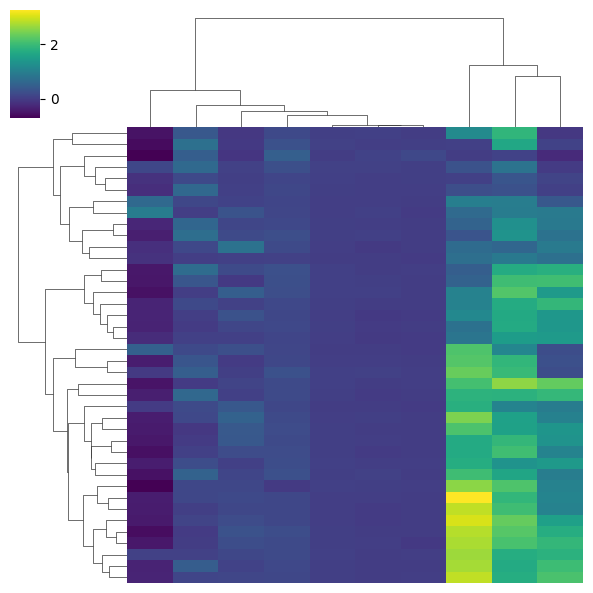

In [239]:
W = ent.model.getExpectations()["W"]
W_lineage = W[2]["E"]   # lineage view
from sklearn.cluster import KMeans
import seaborn as sb

kmeans = KMeans(n_clusters=5, random_state=0)
modules = kmeans.fit_predict(W_lineage)
order = np.argsort(modules)
W_sorted = W_lineage[order, :]
sb.clustermap(
    W_sorted,
    cmap="viridis",
    figsize=(6, 6),
    yticklabels=False,
    xticklabels=False
)

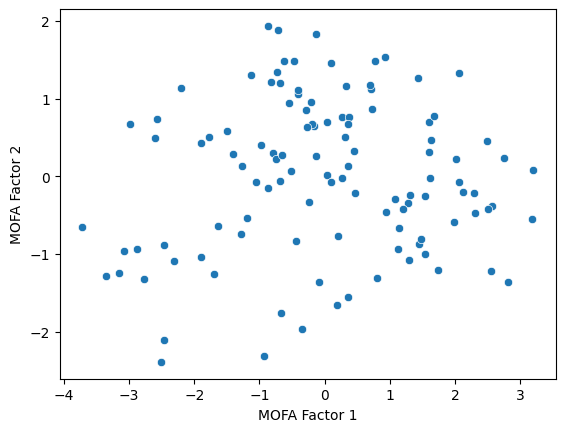

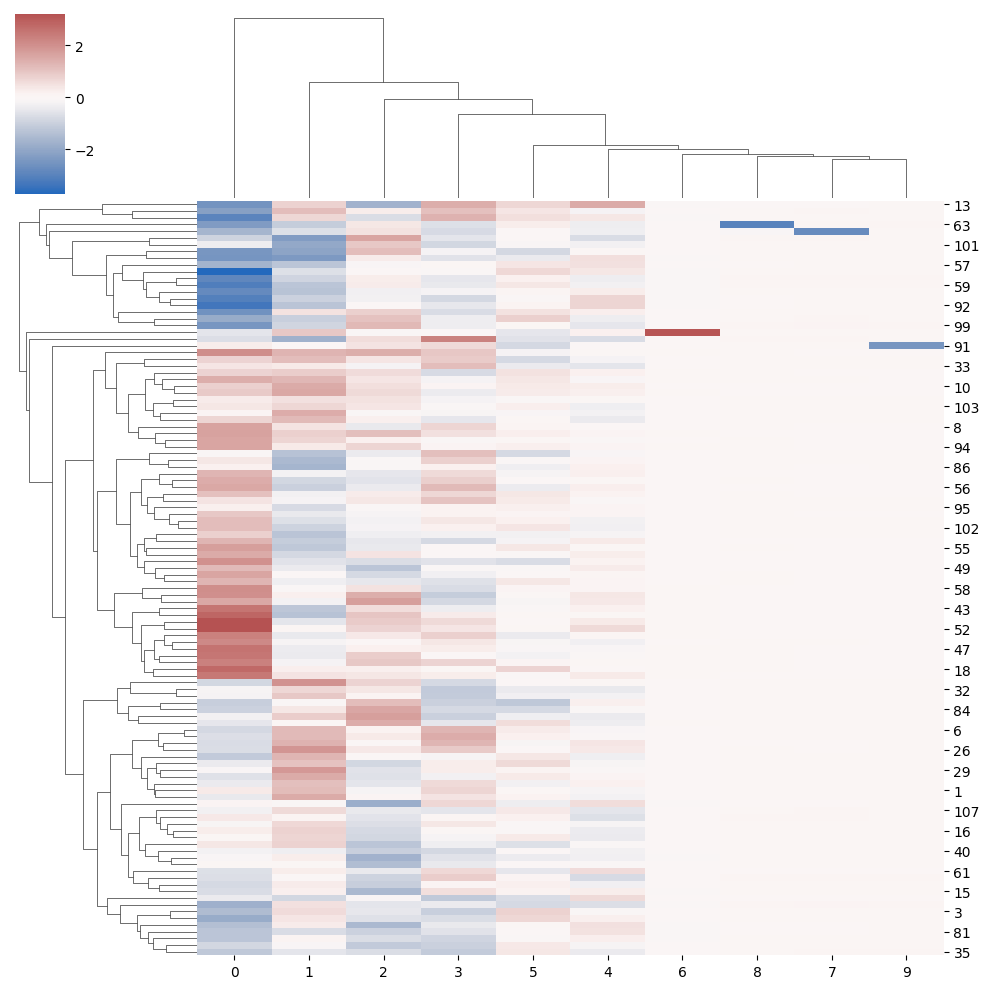

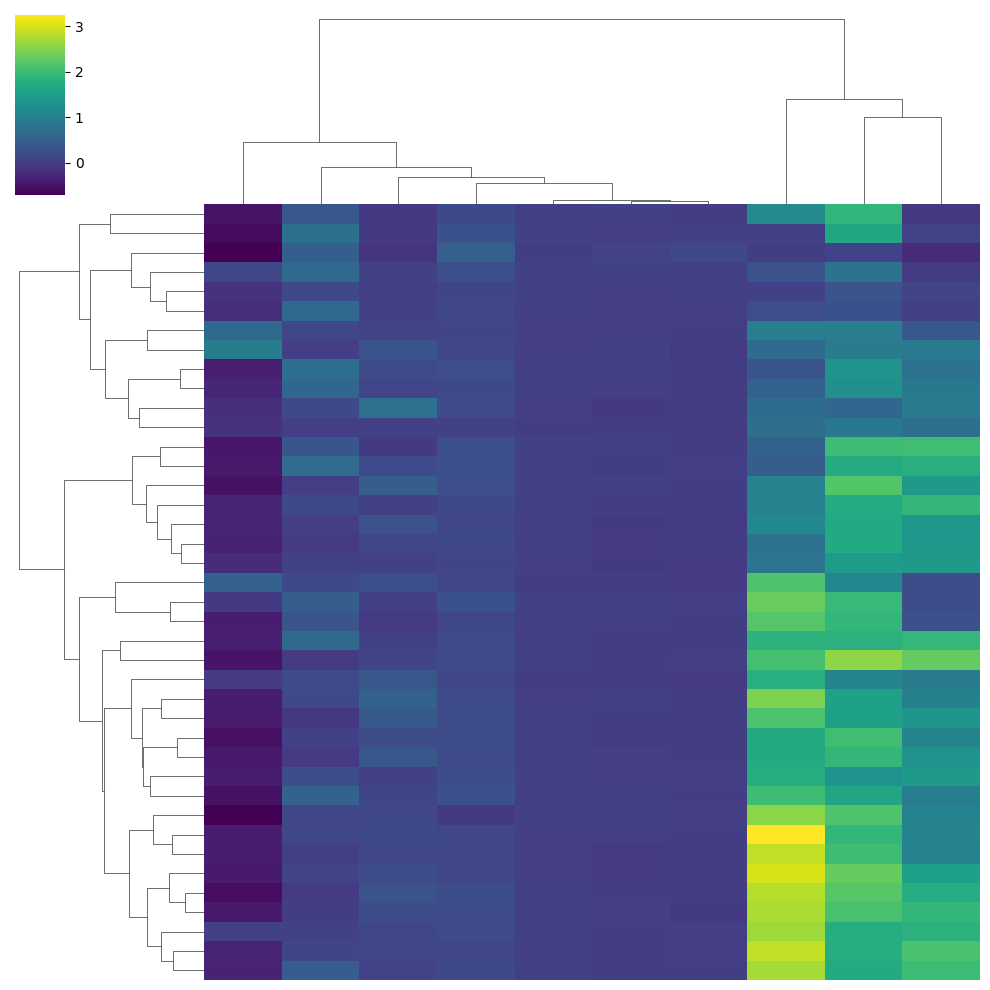

In [240]:
X_lineage = X_bc.reshape(X_bc.shape[0], -1)
Z = ent.model.getExpectations()["Z"]["E"]

import seaborn as sb
import matplotlib.pyplot as plt

sb.scatterplot(
    x=Z[:, 0],
    y=Z[:, 1]
)

plt.xlabel("MOFA Factor 1")
plt.ylabel("MOFA Factor 2")
sb.clustermap(
    Z,
    cmap="vlag",
    center=0
)
W = ent.model.getExpectations()["W"]
W_lineage = W[2]["E"]   # BC view

sb.clustermap(
    W_lineage,
    cmap="viridis",
    xticklabels=False,
    yticklabels=False
)

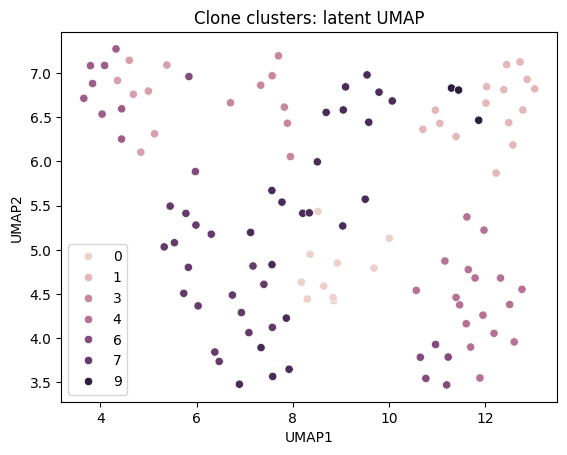

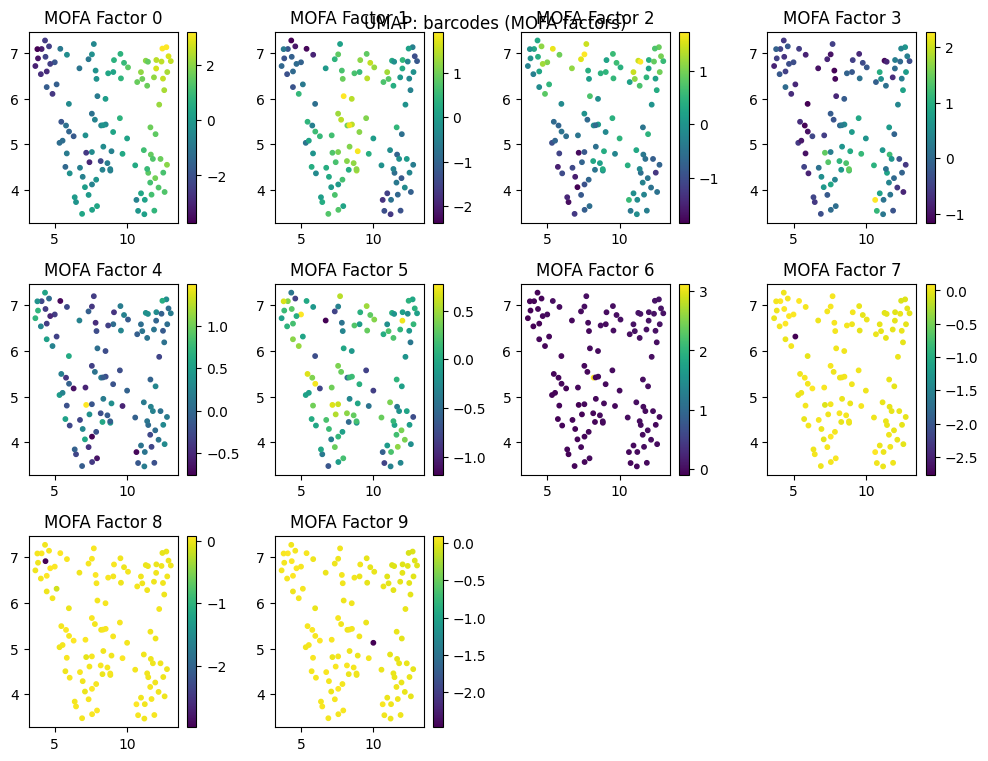

In [241]:
from umap import UMAP
k = Z.shape[1]
Z = ent.model.getExpectations()["Z"]["E"]

X_latent_umap = UMAP(
    n_neighbors=15,
    min_dist=0.3,
    random_state=0
).fit_transform(Z)

from sklearn.cluster import KMeans

clusts = KMeans(n_clusters=k, random_state=0).fit_predict(Z)

import seaborn as sb
import matplotlib.pyplot as plt

sb.scatterplot(
    x=X_latent_umap[:, 0],
    y=X_latent_umap[:, 1],
    hue=clusts
)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("Clone clusters: latent UMAP")
plt.show()

import matplotlib.pyplot as plt

n_factors = Z.shape[1]

plt.figure(figsize=(10, 10))

for i in range(min(n_factors, 16)):
    plt.subplot(4, 4, i+1)

    sc = plt.scatter(
        X_latent_umap[:, 0],
        X_latent_umap[:, 1],
        c=Z[:, i],
        cmap="viridis",
        s=10
    )

    plt.colorbar(sc)
    plt.title(f"MOFA Factor {i}")

plt.tight_layout()
plt.suptitle("UMAP: barcodes (MOFA factors)")
plt.show()

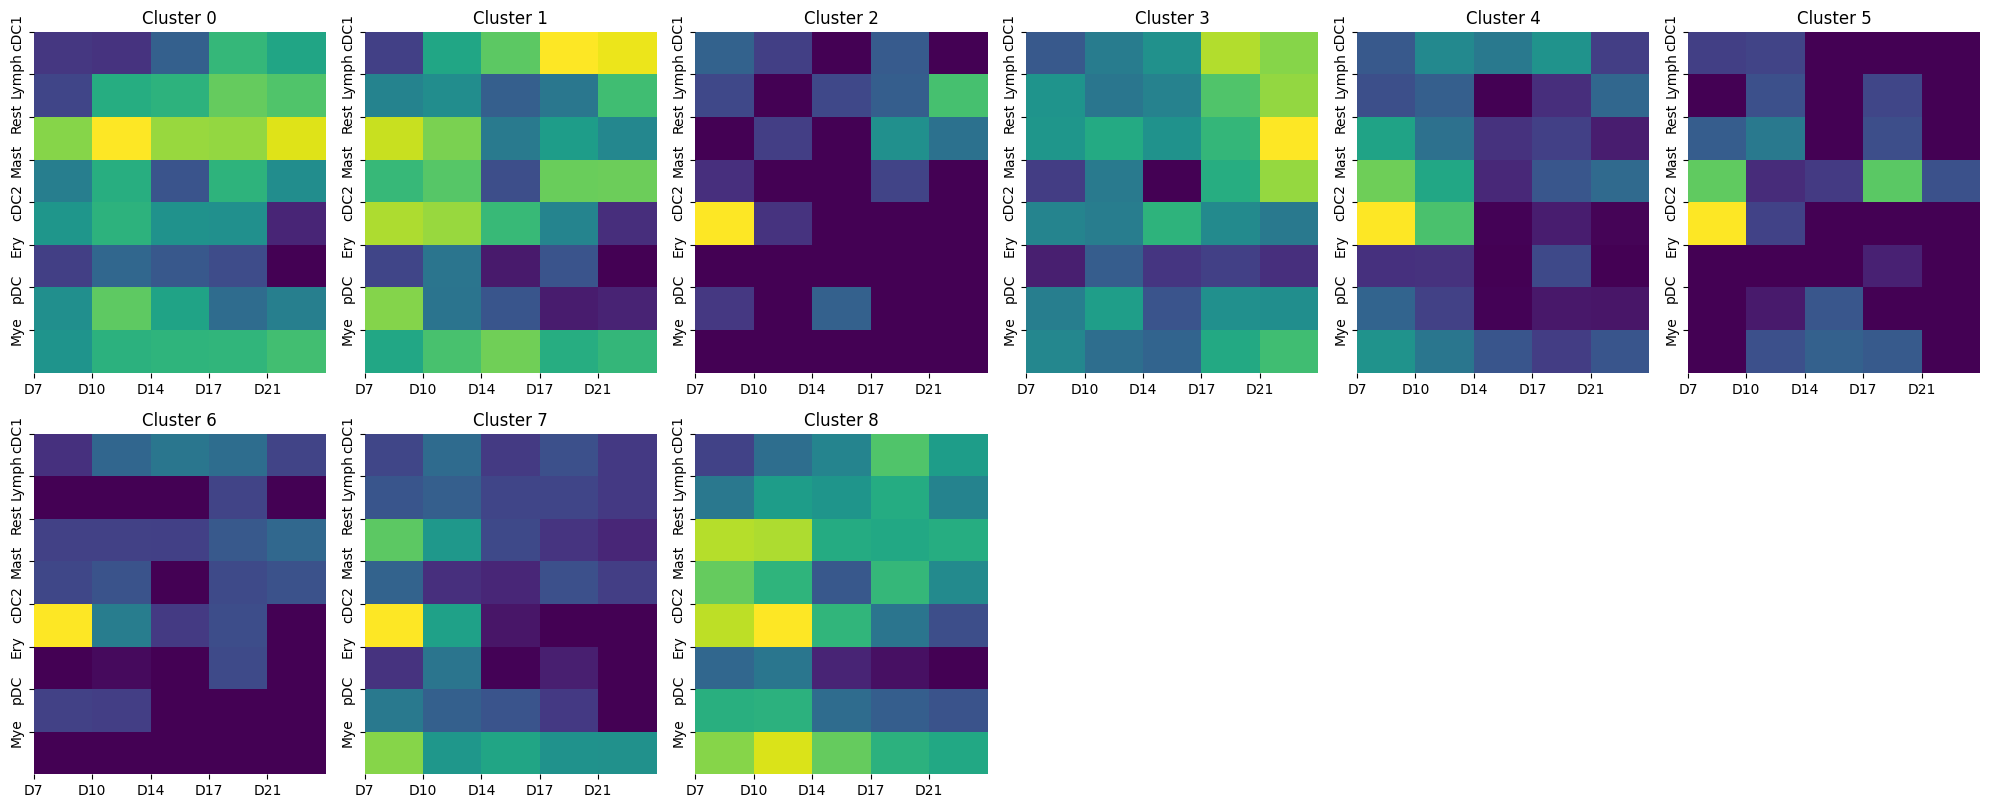

In [242]:
Z = ent.model.getExpectations()["Z"]["E"]      # (112 × K)
W = ent.model.getExpectations()["W"]          # dict per view
X_lineage = X_bc  # (112, 5, 8)
from sklearn.cluster import KMeans

clusts = KMeans(n_clusters=9, random_state=0).fit_predict(Z)
import matplotlib.pyplot as plt
import seaborn as sb

plt.figure(figsize=(20, 20))

for cluster_idx in range(len(np.unique(clusts))):
    plt.subplot(5, 6, cluster_idx+1)

    avg = X_lineage[clusts == cluster_idx].mean(0)  # (5 × 8)

    sb.heatmap(
        avg.T,
        cmap="viridis",
        cbar=False
    )

    plt.yticks(range(8), celltypes)
    plt.xticks(range(5), timepoints)
    plt.title(f"Cluster {cluster_idx}")

plt.tight_layout()
plt.show()

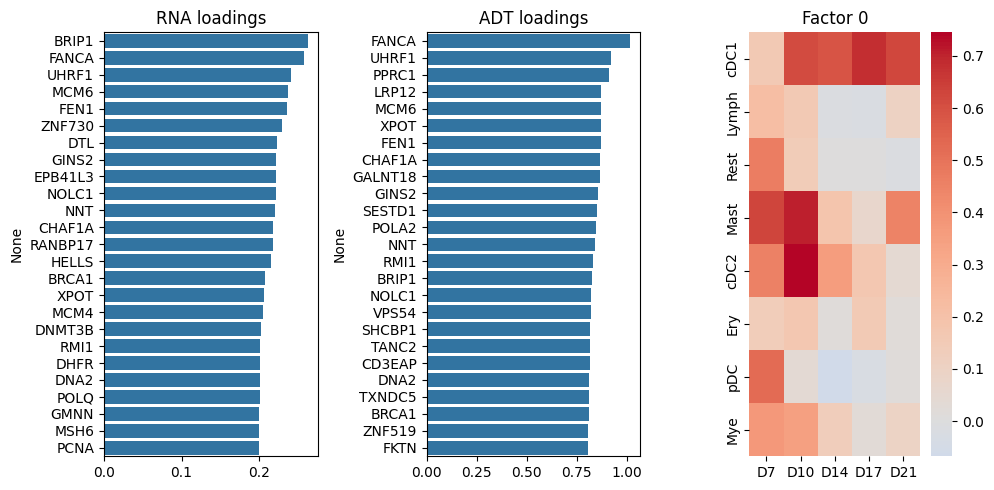

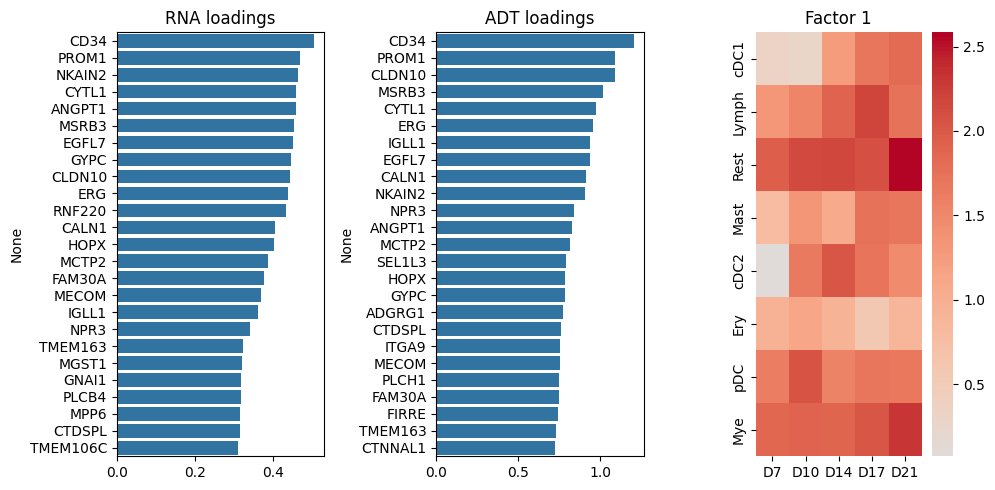

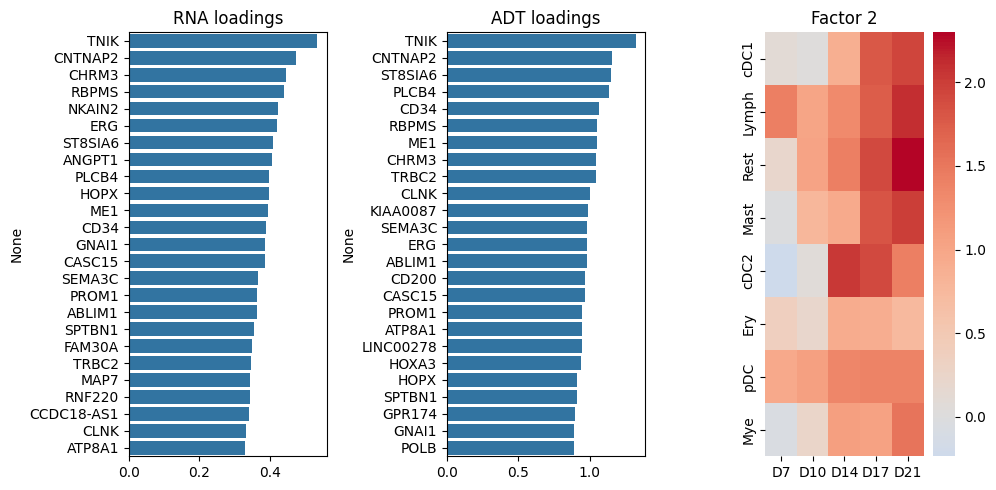

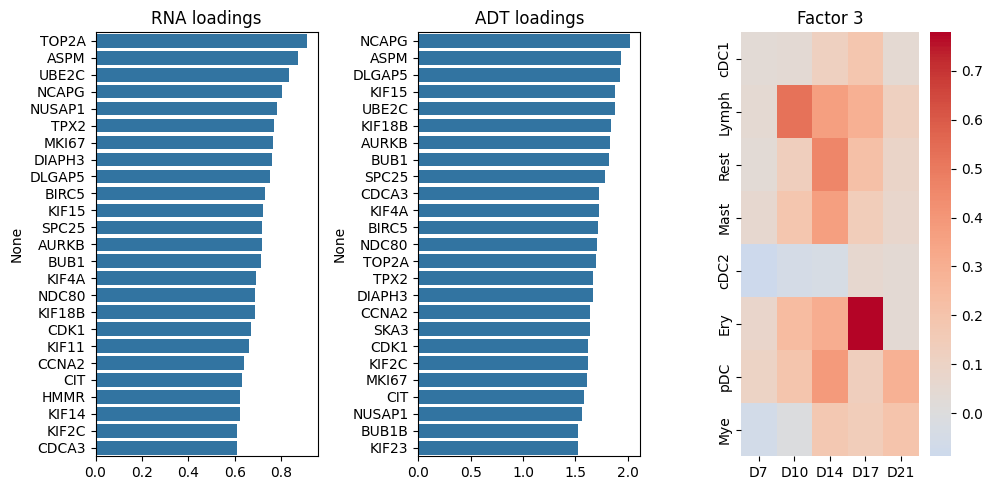

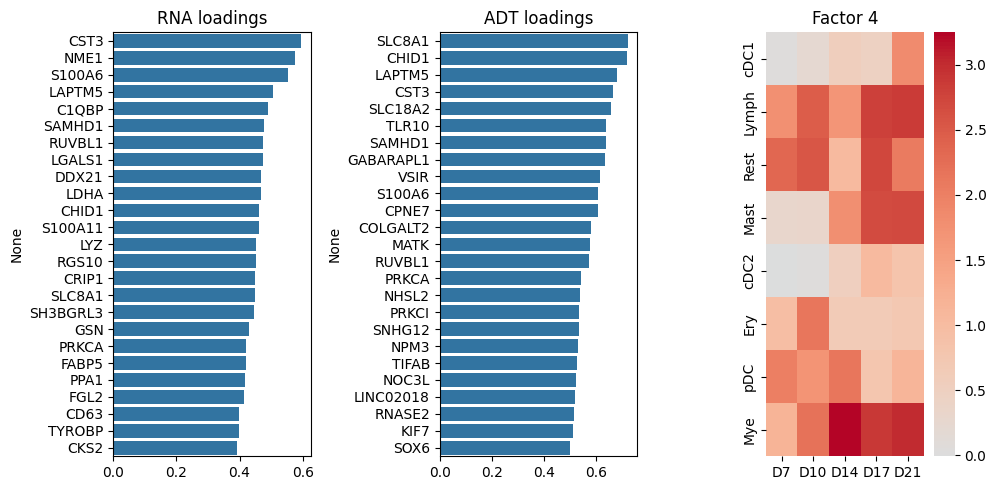

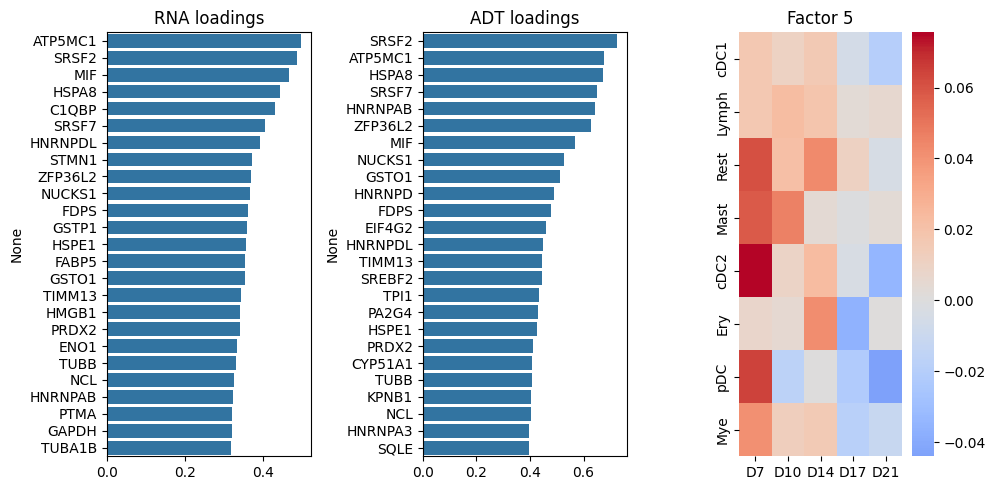

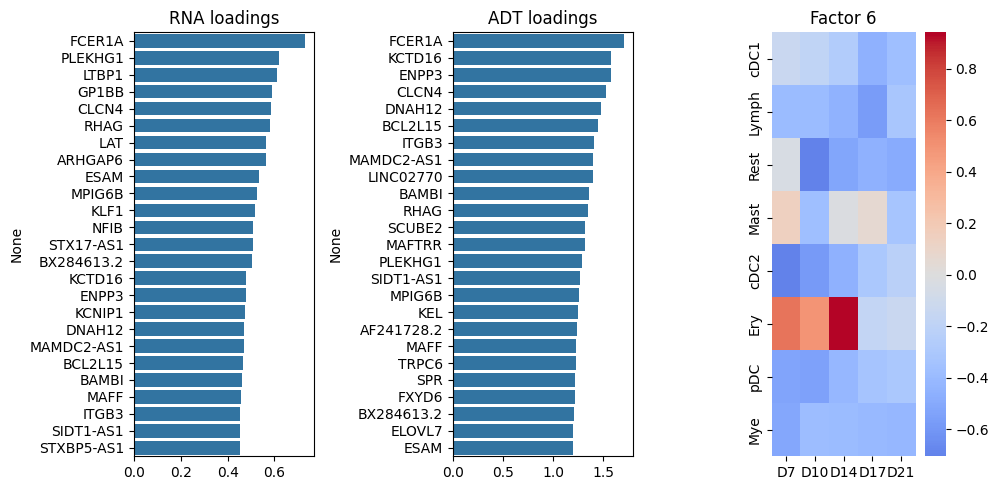

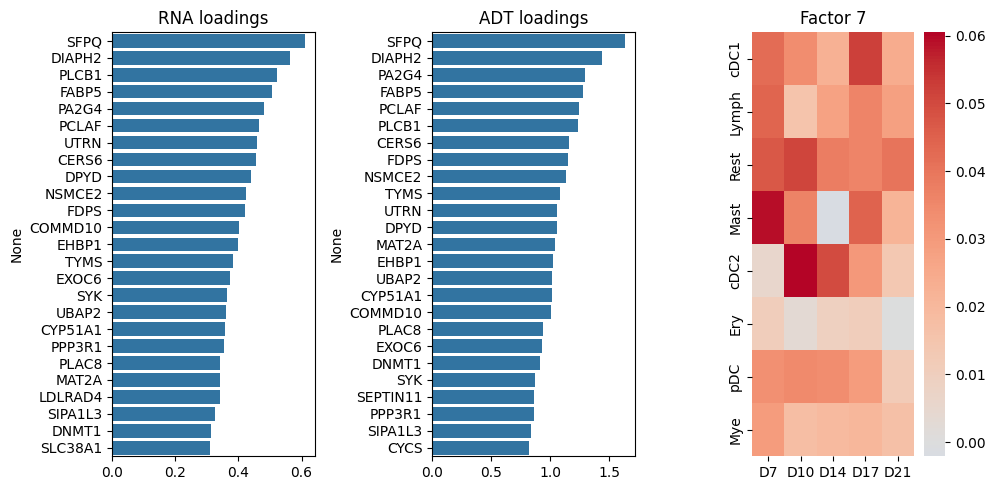

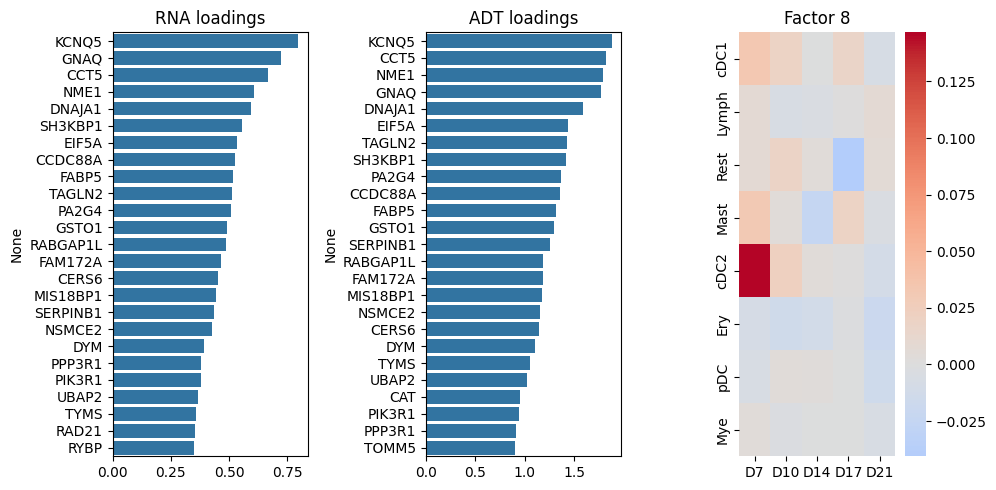

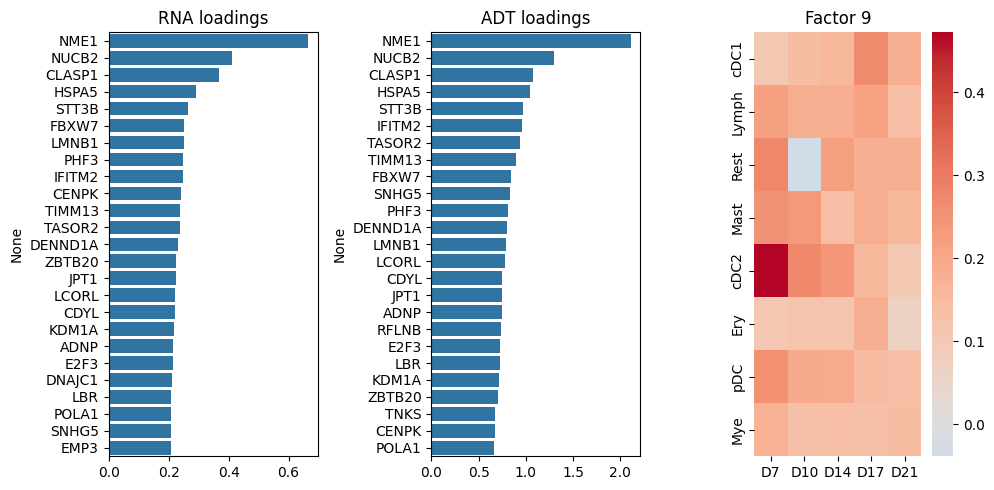

In [243]:
W_rna = W[0]["E"]
W_adt = W[1]["E"]
W_bc  = W[2]["E"]   # flattened 5×8 structure
genes = X_rna.columns
markers = X_adt.columns
n_genes = 25
n_markers = 25

for i in range(Z.shape[1]):

    plt.figure(figsize=(10, 5))

    # -------------------------
    # RNA loadings
    # -------------------------
    plt.subplot(1, 3, 1)

    order = np.argsort(W_rna[:, i])[::-1]
    top_genes = genes[order][:n_genes]
    top_vals = W_rna[order, i][:n_genes]

    sb.barplot(x=top_vals, y=top_genes)
    plt.title("RNA loadings")

    # -------------------------
    # ADT loadings
    # -------------------------
    plt.subplot(1, 3, 2)

    order = np.argsort(W_adt[:, i])[::-1]
    top_markers = markers[order][:n_markers]
    top_vals = W_adt[order, i][:n_markers]

    sb.barplot(x=top_vals, y=top_markers)
    plt.title("ADT loadings")

    # -------------------------
    # lineage structure (5 × 8)
    # -------------------------
    plt.subplot(1, 3, 3)

    lineage = W_bc[:, i].reshape(5, 8)

    sb.heatmap(
        lineage.T,
        cmap="coolwarm",
        center=0,
        xticklabels=timepoints,
        yticklabels=celltypes
    )

    plt.title(f"Factor {i}")

    plt.tight_layout()
    plt.show()